# 01 · Análisis Exploratorio del Catálogo MLC

**Proyecto:** Pricing Health Check para Sellers PYME en MercadoLibre Chile  
**Día:** 2 de 21  
**Autor:** Julio Pradenas

## Objetivos del notebook

1. Cargar el dataset semilla y validar tipos.
2. Cuantificar la **densidad competitiva** por categoría.
3. Caracterizar la **brecha de precio** entre sellers para el mismo producto.
4. Identificar el perfil del seller que está dejando margen sobre la mesa.
5. Definir el hero seller para el caso de estudio del reporte.


## 1 · Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RAW_DIR

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

PALETTE = {
    "primary": "#2563EB",
    "accent":  "#FFE600",
    "warning": "#DC2626",
    "neutral": "#64748B",
    "good":    "#16A34A",
}

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})

Matplotlib is building the font cache; this may take a moment.


## 2 · Carga del dataset

In [2]:
files = sorted(RAW_DIR.glob("highlights_offers_*.parquet"))
assert files, "No hay parquets en data/raw"

df = pd.read_parquet(files[-1])
print(f"Archivo: {files[-1].name}")
print(f"Shape:   {df.shape}")
df.head()

Archivo: highlights_offers_20260507_194630.parquet
Shape:   (348, 25)


,snapshot_date,category_id,category_name,highlight_position,product_id,product_name,domain_id,brand,model,item_id,seller_id,official_store_id,price,original_price,discount_pct,currency_id,condition,listing_type_id,free_shipping,logistic_type,seller_state,accepts_mercadopago,n_competitors,is_min_price,price_gap_to_min_pct
0,2026-05-07 19:45:43.223665+00:00,MLC1055,Celulares y Smartphones,1,MLC54097181,Xiaomi Poco C85 Negro 128 GB ROM 6 GB RAM,MLC-CELLPHONES,Xiaomi,Poco C85,MLC3452712604,550063615,428.0,120810,179990.0,32.88,CLP,new,gold_special,True,fulfillment,RM (Metropolitana),True,2,True,0.00
1,2026-05-07 19:45:43.223665+00:00,MLC1055,Celulares y Smartphones,1,MLC54097181,Xiaomi Poco C85 Negro 128 GB ROM 6 GB RAM,MLC-CELLPHONES,Xiaomi,Poco C85,MLC3521509944,131700946,NaN,120990,NaN,NaN,CLP,new,gold_special,True,fulfillment,RM (Metropolitana),True,2,False,0.15
2,2026-05-07 19:45:43.223665+00:00,MLC1055,Celulares y Smartphones,2,MLC61449318,Motorola Moto G06 4+128 Verde,MLC-CELLPHONES,Motorola,Moto G06,MLC1811578083,1767021504,NaN,94990,NaN,NaN,CLP,new,gold_special,True,drop_off,RM (Metropolitana),True,2,True,0.00
3,2026-05-07 19:45:43.223665+00:00,MLC1055,Celulares y Smartphones,2,MLC61449318,Motorola Moto G06 4+128 Verde,MLC-CELLPHONES,Motorola,Moto G06,MLC3330794132,301258112,299.0,99990,149990.0,33.34,CLP,new,gold_special,True,fulfillment,RM (Metropolitana),True,2,False,5.26
4,2026-05-07 19:45:43.223665+00:00,MLC1055,Celulares y Smartphones,3,MLC22271142,Tecnolab Senior Phone TL038 128 MB rojo 64 MB RAM,MLC-CELLPHONES,Tecnolab,TL038,MLC1853772433,1455465942,NaN,39990,NaN,NaN,CLP,new,gold_special,True,xd_drop_off,RM (Metropolitana),True,7,False,25.01


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   snapshot_date         348 non-null    datetime64[ns, UTC]
 1   category_id           348 non-null    object             
 2   category_name         348 non-null    object             
 3   highlight_position    348 non-null    int64              
 4   product_id            348 non-null    object             
 5   product_name          348 non-null    object             
 6   domain_id             348 non-null    object             
 7   brand                 348 non-null    object             
 8   model                 348 non-null    object             
 9   item_id               348 non-null    object             
 10  seller_id             348 non-null    int64              
 11  official_store_id     102 non-null    float64            
 12  price   

## 3 · Densidad competitiva por categoría

**Pregunta:** ¿Cuántos sellers compiten realmente por un mismo producto en cada categoría?

In [4]:
# TODO: t# Tabla resumen por categoría
resumen_cat = df.groupby("category_name").agg(
    productos=("product_id", "nunique"),
    ofertas=("item_id", "count"),
    sellers=("seller_id", "nunique"),
    competidores_mediana=("n_competitors", "median"),
    competidores_max=("n_competitors", "max"),
    precio_min=("price", "min"),
    precio_max=("price", "max"),
).round(1)

resumen_cat["ofertas_por_producto"] = (resumen_cat["ofertas"] / resumen_cat["productos"]).round(2)
resumen_cat

,productos,ofertas,sellers,competidores_mediana,competidores_max,precio_min,precio_max,ofertas_por_producto
category_name,,,,,,,,
Celulares y Smartphones,15,34,19,3.0,7,31990,1669990,2.27
Computación,20,165,128,13.0,26,2723,749990,8.25
"Electrónica, Audio y Video",19,149,112,14.0,25,7990,149990,7.84


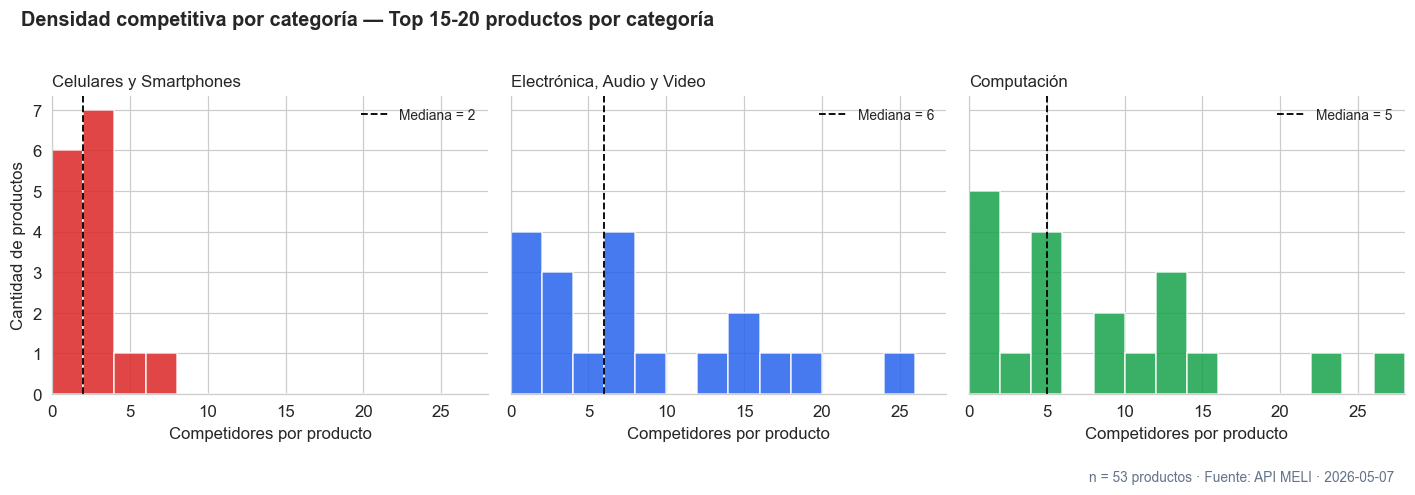

In [6]:
# TODO: # Distribución del número de competidores por producto - facetado
prod_unique = df.drop_duplicates("product_id")[["category_name", "n_competitors"]]

categorias = ["Celulares y Smartphones", "Electrónica, Audio y Video", "Computación"]
colores = [PALETTE["warning"], PALETTE["primary"], PALETTE["good"]]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, cat, color in zip(axes, categorias, colores):
    data = prod_unique[prod_unique["category_name"] == cat]["n_competitors"]
    ax.hist(data, bins=range(0, 30, 2), color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.median(), color="black", linestyle="--", linewidth=1.2,
               label=f"Mediana = {data.median():.0f}")
    ax.set_title(cat, fontsize=11, loc="left")
    ax.set_xlabel("Competidores por producto")
    ax.legend(frameon=False, fontsize=9, loc="upper right")
    ax.set_xlim(0, 28)

axes[0].set_ylabel("Cantidad de productos")
fig.suptitle("Densidad competitiva por categoría — Top 15-20 productos por categoría",
             fontweight="bold", x=0.02, ha="left", y=1.02, fontsize=13)
fig.text(0.98, -0.05,
         f"n = {len(prod_unique)} productos · Fuente: API MELI · {df['snapshot_date'].dt.date.iloc[0]}",
         ha="right", fontsize=9, color=PALETTE["neutral"])

plt.tight_layout()
plt.savefig("../deliverables/fig_01_densidad_competitiva.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 · Brecha de precio entre sellers para el mismo producto

In [7]:
# TODO: # Para cada producto con >=2 sellers, calcular el spread de precio
# spread = (p_max - p_min) / p_min * 100

spreads = (df.groupby(["product_id", "product_name", "category_name"])
             .agg(n=("item_id", "count"),
                  p_min=("price", "min"),
                  p_max=("price", "max"),
                  p_median=("price", "median"))
             .reset_index())

spreads = spreads[spreads["n"] >= 2].copy()
spreads["spread_pct"] = ((spreads["p_max"] - spreads["p_min"]) / spreads["p_min"] * 100).round(1)
spreads["spread_clp"] = (spreads["p_max"] - spreads["p_min"]).astype(int)

print(f"Productos con >=2 sellers: {len(spreads)} de {df['product_id'].nunique()}")
print()
print("Resumen de spreads:")
print(spreads["spread_pct"].describe().round(1))

Productos con >=2 sellers: 39 de 53

Resumen de spreads:
count     39.0
mean      82.8
std       77.0
min        0.0
25%       19.3
50%       70.7
75%      109.8
max      340.0
Name: spread_pct, dtype: float64


/var/folders/n4/hklslsrn5t91cccgjf28xl2c0000gn/T/ipykernel_66760/775610214.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=spreads, x="category_name", y="spread_pct", order=orden,


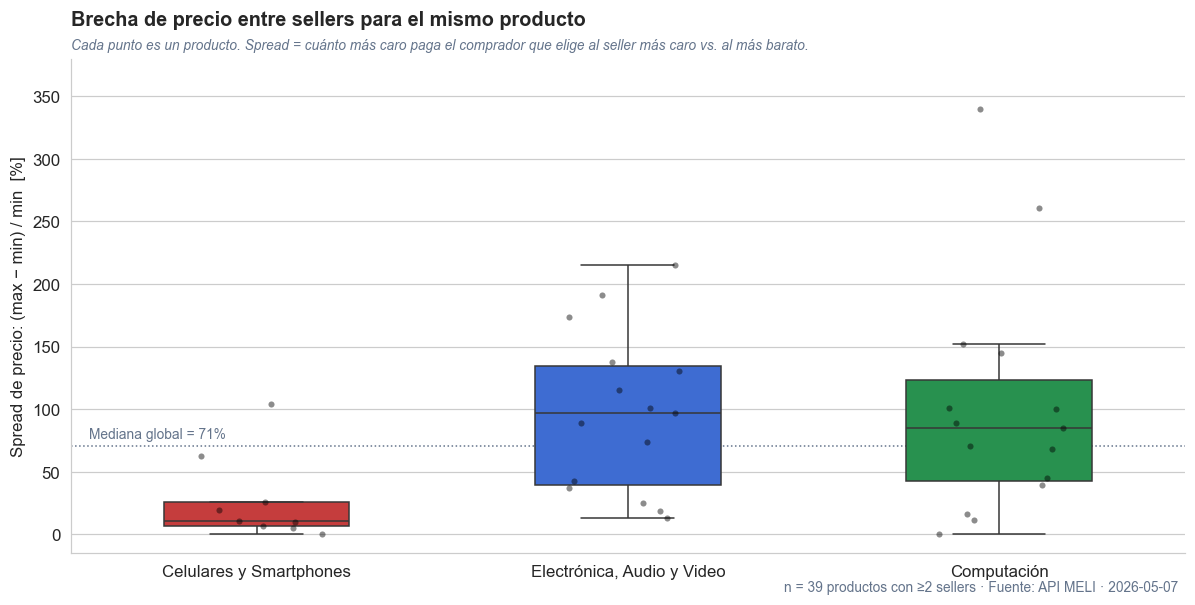

In [9]:
# TODO: # Visualización: distribución de spreads por categoría (boxplot + stripplot)
# Versión limpia del mismo gráfico
fig, ax = plt.subplots(figsize=(11, 5.5))

orden = ["Celulares y Smartphones", "Electrónica, Audio y Video", "Computación"]
color_map = {
    "Celulares y Smartphones": PALETTE["warning"],
    "Electrónica, Audio y Video": PALETTE["primary"],
    "Computación": PALETTE["good"],
}

sns.boxplot(data=spreads, x="category_name", y="spread_pct", order=orden,
            palette=[color_map[c] for c in orden], ax=ax, showfliers=False, width=0.5)
sns.stripplot(data=spreads, x="category_name", y="spread_pct", order=orden,
              color="black", size=4, alpha=0.45, jitter=0.18, ax=ax)

# Mediana global como referencia
mediana_global = spreads["spread_pct"].median()
ax.axhline(mediana_global, color=PALETTE["neutral"], linestyle=":", linewidth=1, zorder=0)
ax.text(-0.45, mediana_global + 6,
        f"Mediana global = {mediana_global:.0f}%",
        fontsize=9, color=PALETTE["neutral"])

ax.set_xlabel("")
ax.set_ylabel("Spread de precio: (max − min) / min  [%]")
ax.set_title(
    "Brecha de precio entre sellers para el mismo producto",
    loc="left", fontweight="bold", pad=22)
ax.text(0, 1.02,
        "Cada punto es un producto. Spread = cuánto más caro paga el comprador que elige al seller más caro vs. al más barato.",
        transform=ax.transAxes, fontsize=9, color=PALETTE["neutral"], style="italic")

ax.set_ylim(-15, 380)

fig.text(0.98, 0.01,
         f"n = {len(spreads)} productos con ≥2 sellers · Fuente: API MELI · {df['snapshot_date'].dt.date.iloc[0]}",
         ha="right", fontsize=9, color=PALETTE["neutral"])

plt.tight_layout()
plt.savefig("../deliverables/fig_02_brechas_precio.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# TODO: # Top 10 productos con mayor spread - el gancho del reporte
top10 = (spreads.sort_values("spread_pct", ascending=False)
                .head(10)
                .reset_index(drop=True))

# Versión imprimible
print("Top 10 productos con mayor brecha de precio entre sellers:")
print()
for i, row in top10.iterrows():
    nombre = row["product_name"][:55]
    print(f"{i+1:2d}. {nombre:<55s} | {row['n']} sellers | "
          f"${row['p_min']:>8,.0f} → ${row['p_max']:>8,.0f} | spread {row['spread_pct']:.0f}%")

Top 10 productos con mayor brecha de precio entre sellers:

 1. Pasta Térmica Arctic Mx-4 De Alto Rendimiento Jeringa 4 | 12 sellers | $   2,723 → $  11,980 | spread 340%
 2. Impresora multifunción HP Smart Tank 580 Tinta Continua | 10 sellers | $ 138,500 → $ 499,990 | spread 261%
 3. Audifonos Bluetooth Inalambricos Blik Soul250 20 Hrs Co | 14 sellers | $   9,990 → $  31,490 | spread 215%
 4. Soporte Tv Rack Movil Con Ruedas 32 A 55 Base Pedestal  | 18 sellers | $  31,990 → $  93,213 | spread 191%
 5. Xiaomi Redmi Buds 6 Play Rosa                           | 9 sellers | $  12,272 → $  33,590 | spread 174%
 6. Mouse Inalambrico Logitech M280 Gris                    | 22 sellers | $  11,900 → $  29,990 | spread 152%
 7. Soporte Ajustable De Aluminio Plegable Para Notebook Ha | 15 sellers | $   3,590 → $   8,804 | spread 145%
 8. Audífono Bluetooth Hoco W35 Air 45hrs Para iPhone O And | 25 sellers | $  11,590 → $  27,600 | spread 138%
 9. Audífonos Inalámbricos Con Noise Cancelling Wh-ch

## 5 · Tienda Oficial vs Seller PYME

In [11]:
# TODO: # Crear flag is_official
df["is_official"] = df["official_store_id"].notna()

# Comparar el price_gap_to_min_pct (qué tan lejos del precio mínimo está cada oferta)
print("Distribución de price_gap_to_min_pct por tipo de seller:")
print()
print(df.groupby("is_official")["price_gap_to_min_pct"].describe().round(2))

print()
print("Wins de precio mínimo:")
wins = (df.groupby("is_official")["is_min_price"]
          .agg(["sum", "count"]))
wins["win_rate_pct"] = (wins["sum"] / wins["count"] * 100).round(1)
wins.index = wins.index.map({True: "Tienda Oficial", False: "Seller PYME"})
print(wins)

Distribución de price_gap_to_min_pct por tipo de seller:

             count   mean    std  min   25%    50%    75%     max
is_official                                                      
False        246.0  46.67  51.33  0.0  9.08  32.89  68.28  339.96
True         102.0  18.11  21.89  0.0  0.00   9.84  29.66   85.00

Wins de precio mínimo:
                sum  count  win_rate_pct
is_official                             
Seller PYME      25    246          10.2
Tienda Oficial   33    102          32.4


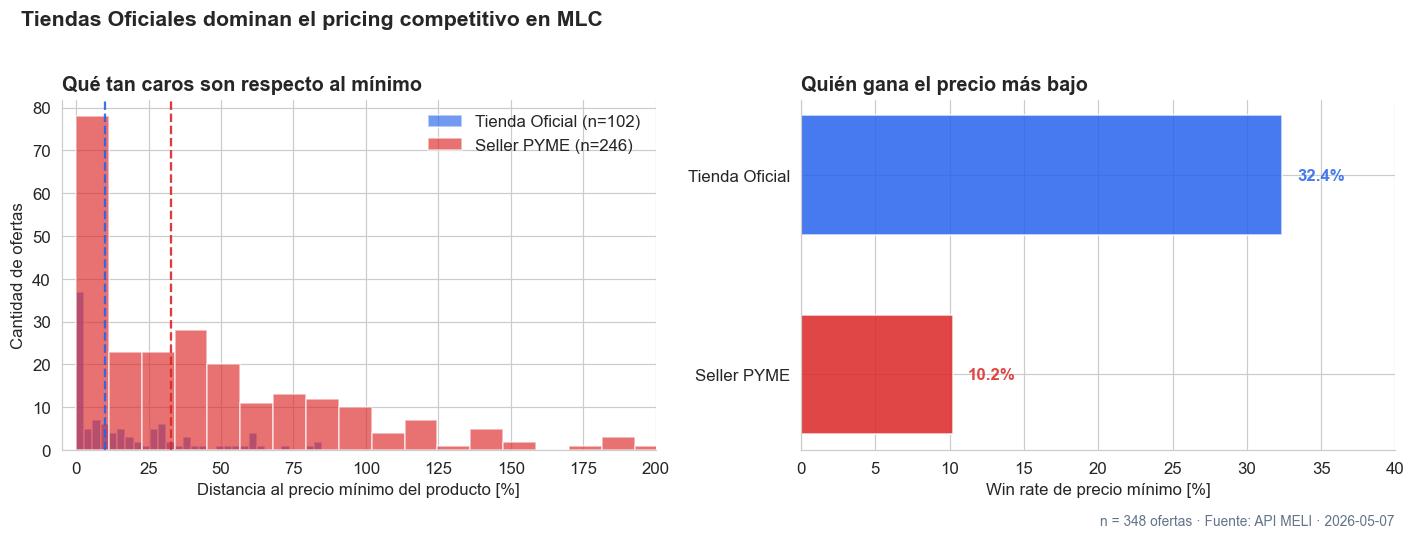

In [12]:
# TODO: # Visualización: distribución de price_gap_to_min_pct por tipo de seller
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel izquierdo: distribución de gap
ax = axes[0]
for is_off, color, label in [(True, PALETTE["primary"], "Tienda Oficial"),
                              (False, PALETTE["warning"], "Seller PYME")]:
    data = df[df["is_official"] == is_off]["price_gap_to_min_pct"]
    ax.hist(data, bins=30, alpha=0.65, color=color, label=f"{label} (n={len(data)})",
            edgecolor="white")
    ax.axvline(data.median(), color=color, linestyle="--", linewidth=1.5, alpha=0.9)

ax.set_xlabel("Distancia al precio mínimo del producto [%]")
ax.set_ylabel("Cantidad de ofertas")
ax.set_title("Qué tan caros son respecto al mínimo", loc="left", fontweight="bold")
ax.legend(frameon=False)
ax.set_xlim(-5, 200)

# Panel derecho: win rate
ax = axes[1]
labels = ["Seller PYME", "Tienda Oficial"]
values = [10.2, 32.4]
colors_b = [PALETTE["warning"], PALETTE["primary"]]
bars = ax.barh(labels, values, color=colors_b, alpha=0.85, edgecolor="white", height=0.6)

for bar, val in zip(bars, values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f"{val:.1f}%",
            va="center", fontsize=11, fontweight="bold", color=bar.get_facecolor())

ax.set_xlabel("Win rate de precio mínimo [%]")
ax.set_xlim(0, 40)
ax.set_title("Quién gana el precio más bajo", loc="left", fontweight="bold")

fig.suptitle("Tiendas Oficiales dominan el pricing competitivo en MLC",
             fontweight="bold", x=0.02, ha="left", y=1.02, fontsize=14)
fig.text(0.98, -0.02,
         f"n = {len(df)} ofertas · Fuente: API MELI · {df['snapshot_date'].dt.date.iloc[0]}",
         ha="right", fontsize=9, color=PALETTE["neutral"])

plt.tight_layout()
plt.savefig("../deliverables/fig_03_oficial_vs_pyme.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 · Logística y listing type como variables competitivas

In [13]:
# TODO: cross-tab logistic_type x is_min_price
# Cross-tab: logistic_type vs is_min_price
print("Win rate de precio mínimo según tipo de logística:")
print()

logistic_winrate = (df.groupby("logistic_type")
                      .agg(ofertas=("item_id", "count"),
                           wins=("is_min_price", "sum"),
                           gap_mediano=("price_gap_to_min_pct", "median"))
                      .sort_values("ofertas", ascending=False))

logistic_winrate["win_rate_pct"] = (logistic_winrate["wins"] / logistic_winrate["ofertas"] * 100).round(1)
logistic_winrate["gap_mediano"] = logistic_winrate["gap_mediano"].round(1)

print(logistic_winrate)

Win rate de precio mínimo según tipo de logística:

               ofertas  wins  gap_mediano  win_rate_pct
logistic_type                                          
xd_drop_off        165     5         40.0           3.0
fulfillment        106    42          4.3          39.6
cross_docking       68     7         25.5          10.3
drop_off             7     3          3.7          42.9
not_specified        2     1         12.5          50.0


                 ofertas  wins  gap_mediano  precio_mediano  win_rate_pct
listing_type_id                                                          
gold_special         261    41         22.3           25480          15.7
gold_pro              87    17         29.0           31990          19.5

Mix por tipo de listing en el dataset:
listing_type_id
gold_special    75.0
gold_pro        25.0
Name: proportion, dtype: float64


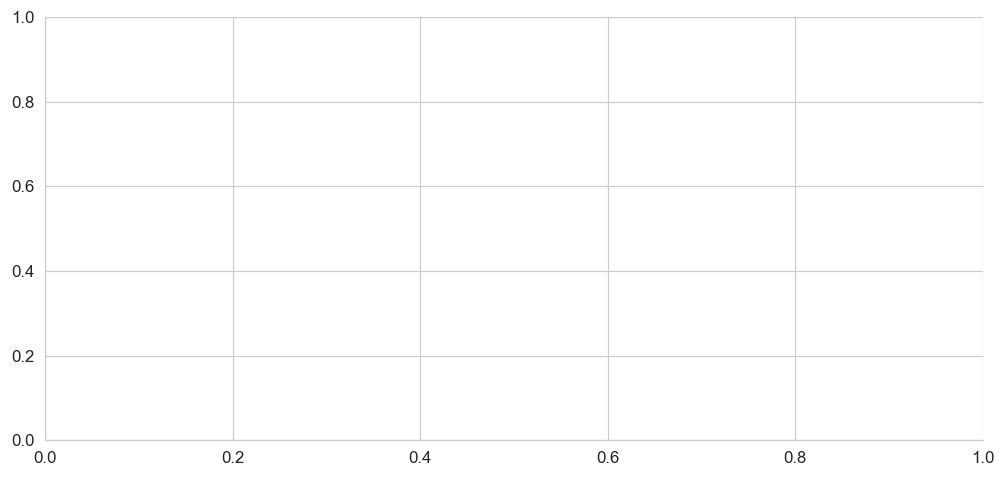

In [16]:
# TODO: gold_special vs gold_pro
# Listing type performance
listing_perf = (df.groupby("listing_type_id")
                  .agg(ofertas=("item_id", "count"),
                       wins=("is_min_price", "sum"),
                       gap_mediano=("price_gap_to_min_pct", "median"),
                       precio_mediano=("price", "median"))
                  .sort_values("ofertas", ascending=False))

listing_perf["win_rate_pct"] = (listing_perf["wins"] / listing_perf["ofertas"] * 100).round(1)
listing_perf["gap_mediano"] = listing_perf["gap_mediano"].round(1)
listing_perf["precio_mediano"] = listing_perf["precio_mediano"].astype(int)

print(listing_perf)
print()
print("Mix por tipo de listing en el dataset:")
print((df["listing_type_id"].value_counts(normalize=True) * 100).round(1))


#-----------------------------------------------------------------------------------------------------------------
# Visualización del impacto logístico
fig, ax = plt.subplots(figsize=(11, 5))

# Filtrar tipos con n suficiente
logi = logistic_winrate[logistic_winrate["ofertas"] >= 5].copy()
logi = logi.sort_values("win_rate_pct", ascending=True)

# Mapeo de nombres legibles


## 7 · Identificación del Hero Seller

**Criterios:**
1. >=5 ofertas en el dataset.
2. NO tiene tienda oficial.
3. No es precio mínimo en >=30% de sus listings.
4. Productos en al menos 2 categorías.

In [17]:
# TODO: ranking de sellers según los criterios
# Ranking de sellers según los criterios:
# 1. >=5 ofertas en el dataset
# 2. NO tiene tienda oficial
# 3. No es precio mínimo en >=30% de sus listings
# 4. Productos en al menos 2 categorías

seller_profile = (df.groupby("seller_id")
                    .agg(ofertas=("item_id", "count"),
                         categorias=("category_name", "nunique"),
                         productos=("product_id", "nunique"),
                         es_oficial=("is_official", "any"),
                         wins=("is_min_price", "sum"),
                         gap_promedio=("price_gap_to_min_pct", "mean"),
                         gap_max=("price_gap_to_min_pct", "max"),
                         precio_mediano=("price", "median"))
                    .reset_index())

seller_profile["win_rate_pct"] = (seller_profile["wins"] / seller_profile["ofertas"] * 100).round(1)
seller_profile["loss_rate_pct"] = (100 - seller_profile["win_rate_pct"]).round(1)
seller_profile["gap_promedio"] = seller_profile["gap_promedio"].round(1)
seller_profile["gap_max"] = seller_profile["gap_max"].round(1)

# Aplicar filtros del hero seller
candidatos = seller_profile[
    (seller_profile["ofertas"] >= 5)
    & (~seller_profile["es_oficial"])
    & (seller_profile["loss_rate_pct"] >= 30)
    & (seller_profile["categorias"] >= 2)
].sort_values("ofertas", ascending=False)

print(f"Candidatos a hero seller: {len(candidatos)}")
print()
print(candidatos[["seller_id", "ofertas", "productos", "categorias",
                  "win_rate_pct", "gap_promedio", "gap_max",
                  "precio_mediano"]].to_string(index=False))

Candidatos a hero seller: 3

 seller_id  ofertas  productos  categorias  win_rate_pct  gap_promedio  gap_max  precio_mediano
1310149720        7          7           2           0.0         164.7    340.0         33590.0
 331070835        5          5           2           0.0          24.0     43.4         39990.0
2570258209        5          5           2          40.0          15.2     47.6        114190.0


## 8 · Conclusiones del EDA

- Hallazgo confirmado:
- Hero seller seleccionado:
- Datos faltantes:
- Próximos pasos:

In [18]:
# Profile detallado del hero seller seleccionado
HERO_ID = 1310149720

hero_offers = df[df["seller_id"] == HERO_ID].copy()

print(f"=== Hero seller: {HERO_ID} (anonimizado como 'ElectroChile' en el reporte) ===")
print()
print(f"Ofertas activas:        {len(hero_offers)}")
print(f"Categorías:             {hero_offers['category_name'].unique().tolist()}")
print(f"Logística predominante: {hero_offers['logistic_type'].mode()[0]}")
print(f"Listing type:           {hero_offers['listing_type_id'].mode()[0]}")
print(f"Precio mediano:         ${hero_offers['price'].median():,.0f}")
print()
print("=== Ofertas detalladas ===")
display_cols = ["product_name", "price", "price_gap_to_min_pct",
                "n_competitors", "logistic_type", "is_min_price"]
hero_view = hero_offers[display_cols].copy()
hero_view["product_name"] = hero_view["product_name"].str[:50]
hero_view = hero_view.sort_values("price_gap_to_min_pct", ascending=False)
print(hero_view.to_string(index=False))

=== Hero seller: 1310149720 (anonimizado como 'ElectroChile' en el reporte) ===

Ofertas activas:        7
Categorías:             ['Electrónica, Audio y Video', 'Computación']
Logística predominante: xd_drop_off
Listing type:           gold_pro
Precio mediano:         $33,590

=== Ofertas detalladas ===
                                      product_name  price  price_gap_to_min_pct  n_competitors logistic_type  is_min_price
Pasta Térmica Arctic Mx-4 De Alto Rendimiento Jeri  11980                339.96             12   xd_drop_off         False
Audifonos Bluetooth Inalambricos Blik Soul250 20 H  31490                215.22             14   fulfillment         False
                     Xiaomi Redmi Buds 6 Play Rosa  33590                173.71              9   xd_drop_off         False
              Mouse Inalambrico Logitech M280 Gris  29990                152.02             22   xd_drop_off         False
                Audifonos Redmi Buds 6 Active Pink  45140                115.05

In [ ]:
## 8 · Conclusiones del EDA

### Hallazgos principales (cuantificados)

1. **Catálogo MLC sin Buy Box winner declarado.** En 53 productos best-seller analizados, 0 tienen `buy_box_winner` activo en la API, contra el patrón de Amazon donde el sistema centraliza al ganador. MELI usa señales implícitas (logística + precio).

2. **Densidad competitiva muy desigual.** Celulares tiene mediana de 2 competidores por producto (catálogo dormido); Audio y Computación tienen mediana de 5-6 con casos de hasta 28 sellers compitiendo.

3. **Brechas de precio masivas.** En productos con ≥2 sellers, el spread mediano es 71%, con casos extremos hasta 340%. Mismo SKU, distintos sellers, hasta 4.4x de diferencia.

4. **Tiendas Oficiales dominan.** Win rate 32% vs 10% de PYME; cuando no ganan, las oficiales están a 18% del mínimo, las PYME a 47%.

5. **MELI Full es el verdadero motor del Buy Box implícito.** Self-shipping (xd_drop_off) gana solo 3%; MELI Full gana 40%. Sin Full, el pricing es secundario.

6. **Listing premium no compensa logística mala.** Gold_pro gana 4 puntos más que gold_special pero termina 7% más caro respecto al mínimo.

### Hero seller seleccionado: `1310149720` ("ElectroChile")

PYME con 7 ofertas en Audio y Computación. **Win rate 0%**, gap promedio 165%. 5 de 7 ofertas usan self-shipping, paga listing gold_pro sin obtener retorno. Caso paradigmático del seller PYME que paga features premium con base logística incorrecta.

### Datos faltantes

- Visitas/conversiones por listing (requiere endpoint autenticado del seller, no accesible para terceros).
- Histórico de precios (la API solo devuelve snapshot actual).
- Ventas reales (`sold_quantity` no es público en MLC).

### Próximos pasos (Día 3)

- Cuantificar elasticidad de precio descriptiva por categoría (con caveats de no-causalidad).
- Diseñar los 3 escenarios de repricing para ElectroChile.
- Calcular ROI proyectado de migrar a MELI Full.

## 8 · Conclusiones del EDA

### Hallazgos principales (cuantificados)

1. **Catálogo MLC sin Buy Box winner declarado.** En 53 productos best-seller analizados, 0 tienen `buy_box_winner` activo en la API, contra el patrón de Amazon donde el sistema centraliza al ganador. MELI usa señales implícitas (logística + precio).

2. **Densidad competitiva muy desigual.** Celulares tiene mediana de 2 competidores por producto (catálogo dormido); Audio y Computación tienen mediana de 5-6 con casos de hasta 28 sellers compitiendo.

3. **Brechas de precio masivas.** En productos con ≥2 sellers, el spread mediano es 71%, con casos extremos hasta 340%. Mismo SKU, distintos sellers, hasta 4.4x de diferencia.

4. **Tiendas Oficiales dominan.** Win rate 32% vs 10% de PYME; cuando no ganan, las oficiales están a 18% del mínimo, las PYME a 47%.

5. **MELI Full es el verdadero motor del Buy Box implícito.** Self-shipping (xd_drop_off) gana solo 3%; MELI Full gana 40%. Sin Full, el pricing es secundario.

6. **Listing premium no compensa logística mala.** Gold_pro gana 4 puntos más que gold_special pero termina 7% más caro respecto al mínimo.

### Hero seller seleccionado: `1310149720` ("ElectroChile")

PYME con 7 ofertas en Audio y Computación. **Win rate 0%**, gap promedio 165%. 5 de 7 ofertas usan self-shipping, paga listing gold_pro sin obtener retorno. Caso paradigmático del seller PYME que paga features premium con base logística incorrecta.

### Datos faltantes

- Visitas/conversiones por listing (requiere endpoint autenticado del seller, no accesible para terceros).
- Histórico de precios (la API solo devuelve snapshot actual).
- Ventas reales (`sold_quantity` no es público en MLC).

### Próximos pasos (Día 3)

- Cuantificar elasticidad de precio descriptiva por categoría (con caveats de no-causalidad).
- Diseñar los 3 escenarios de repricing para ElectroChile.
- Calcular ROI proyectado de migrar a MELI Full.